In [11]:
import jax
import jax.numpy as jnp
import jax.random as jrandom
import equinox as eqx
import diffrax
import optax
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

In [ ]:
all_spirals = {
    "100": jnp.load("spirals_100.npz"),
    "75": jnp.load("spirals_75.npz"),
    "50": jnp.load("spirals_50.npz"),
    "25": jnp.load("spirals_25.npz"),
}
key = "100"
spirals = all_spirals[key]

In [13]:
data_train = spirals["data_train"]
data_val = spirals["data_validation"]
data_test = spirals["data_test"]
alpha_train = spirals["alpha_train"]
alpha_validation = spirals["alpha_validation"]

ts_train = data_train[..., 0]
obs_train = data_train[..., 1:]

obs_mean = jnp.mean(obs_train, axis=(0, 1), keepdims=True)
obs_std = jnp.std(obs_train, axis=(0, 1), keepdims=True)

obs_train_norm = (obs_train - obs_mean) / obs_std

alpha_mean = jnp.mean(alpha_train)
alpha_std = jnp.std(alpha_train)
alpha_train_norm = (alpha_train - alpha_mean) / alpha_std

ts_train = jnp.asarray(ts_train)
obs_train_norm = jnp.asarray(obs_train_norm)
alpha_train_norm = jnp.asarray(alpha_train_norm)

print(f"Time shape: {ts_train.shape}")
print(f"Obs shape: {obs_train_norm.shape}")

Time shape: (1000, 100)
Obs shape: (1000, 100, 2)


In [14]:
class VectorField(eqx.Module):
    net: eqx.nn.MLP

    def __init__(self, hidden_size, width_size, depth, key):
        self.net = eqx.nn.MLP(
            in_size=hidden_size,
            out_size=hidden_size,
            width_size=width_size,
            depth=depth,
            activation=jax.nn.softplus, # Smooth activation for ODEs
            key=key
        )

    def __call__(self, t, y, args):
        return self.net(y)

In [15]:
class ODERNN(eqx.Module):
    vector_field: VectorField
    rnn_cell: eqx.nn.GRUCell
    linear_out: eqx.nn.Linear
    hidden_size: int

    def __init__(self, in_size, hidden_size, out_size, key):
        k1, k2, k3 = jrandom.split(key, 3)
        self.hidden_size = hidden_size
        
        self.vector_field = VectorField(hidden_size, hidden_size, 2, k1)
        
        self.rnn_cell = eqx.nn.GRUCell(in_size, hidden_size, key=k2)
        
        self.linear_out = eqx.nn.Linear(hidden_size, out_size, key=k3)

    def __call__(self, ts, obs):
        h0 = jnp.zeros(self.hidden_size)
        
        init_carry = (h0, ts[0])
        xs = (ts[1:], obs[1:])

        def scan_fn(carry, x):
            h_prev, t_prev = carry
            t_curr, obs_curr = x
            
            sol = diffrax.diffeqsolve(
                diffrax.ODETerm(self.vector_field),
                diffrax.Tsit5(),
                t0=t_prev,
                t1=t_curr,
                dt0=t_curr - t_prev,
                y0=h_prev
            )
            h_ode = sol.ys[0]

            h_next = self.rnn_cell(obs_curr, h_ode)

            return (h_next, t_curr), None

        (h_final, _), _ = jax.lax.scan(scan_fn, init_carry, xs)

        return self.linear_out(h_final)

Starting training...


  0%|          | 0/25 [00:00<?, ?it/s]

Epoch 1/25 | Loss: 0.9170
Epoch 2/25 | Loss: 0.5399
Epoch 3/25 | Loss: 0.2733
Epoch 4/25 | Loss: 0.1611
Epoch 5/25 | Loss: 0.1538
Epoch 6/25 | Loss: 0.1054
Epoch 7/25 | Loss: 0.0549
Epoch 8/25 | Loss: 0.0310
Epoch 9/25 | Loss: 0.0244
Epoch 10/25 | Loss: 0.0184
Epoch 11/25 | Loss: 0.0104
Epoch 12/25 | Loss: 0.0118
Epoch 13/25 | Loss: 0.0123
Epoch 14/25 | Loss: 0.0103
Epoch 15/25 | Loss: 0.0097
Epoch 16/25 | Loss: 0.0084
Epoch 17/25 | Loss: 0.0090
Epoch 18/25 | Loss: 0.0086
Epoch 19/25 | Loss: 0.0080
Epoch 20/25 | Loss: 0.0076
Epoch 21/25 | Loss: 0.0069
Epoch 22/25 | Loss: 0.0069
Epoch 23/25 | Loss: 0.0064
Epoch 24/25 | Loss: 0.0064
Epoch 25/25 | Loss: 0.0064


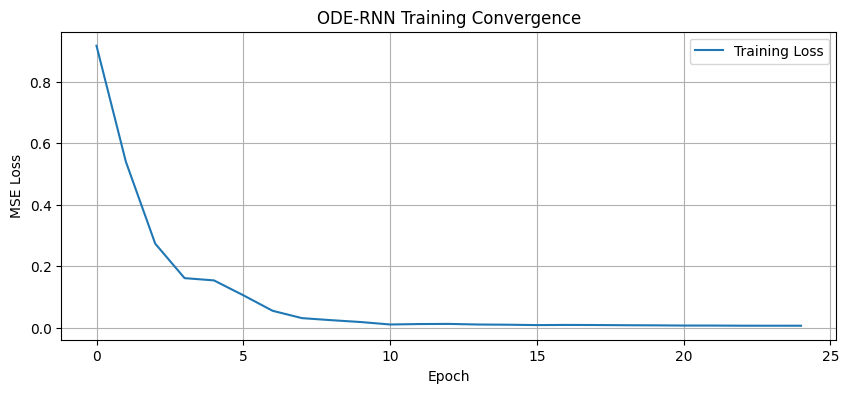

In [16]:
BATCH_SIZE = 256
HIDDEN_SIZE = 32
LEARNING_RATE = 3e-3
EPOCHS = 25

key = jrandom.PRNGKey(567)
model = ODERNN(in_size=2, hidden_size=HIDDEN_SIZE, out_size=1, key=key)

optimizer = optax.adamw(LEARNING_RATE)
opt_state = optimizer.init(eqx.filter(model, eqx.is_array))

@eqx.filter_value_and_grad
def loss_fn(model, batch_ts, batch_obs, batch_y):
    pred_y = jax.vmap(model)(batch_ts, batch_obs)
    return jnp.mean((pred_y - batch_y) ** 2)

@eqx.filter_jit
def make_step(model, opt_state, batch_ts, batch_obs, batch_y):
    loss, grads = loss_fn(model, batch_ts, batch_obs, batch_y)
    updates, opt_state = optimizer.update(grads, opt_state, model)
    model = eqx.apply_updates(model, updates)
    return model, opt_state, loss

def dataloader(ts, obs, y, batch_size, key):
    dataset_size = ts.shape[0]
    indices = jnp.arange(dataset_size)
    perm = jrandom.permutation(key, indices)
    start = 0
    while start < dataset_size:
        batch_idx = perm[start : start + batch_size]
        yield ts[batch_idx], obs[batch_idx], y[batch_idx]
        start += batch_size
        
loss_history = []

print("Starting training...")
for epoch in tqdm(range(EPOCHS)):
    key, subkey = jrandom.split(key)
    epoch_loss = 0
    steps = 0
    
    for batch_ts, batch_obs, batch_y in dataloader(ts_train, obs_train_norm, alpha_train_norm, BATCH_SIZE, subkey):
        model, opt_state, loss = make_step(model, opt_state, batch_ts, batch_obs, batch_y)
        epoch_loss += loss.item()
        steps += 1
        
    avg_loss = epoch_loss / steps
    loss_history.append(avg_loss)
    
    print(f"Epoch {epoch+1}/{EPOCHS} | Loss: {avg_loss:.4f}")
    
plt.figure(figsize=(10, 4))
plt.plot(loss_history, label='Training Loss')
plt.title("ODE-RNN Training Convergence")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.grid(True)
plt.legend()
plt.show()


In [17]:
def predict(data):
    ts = data[..., 0]
    obs = data[..., 1:]

    obs_norm = (obs - obs_mean) / obs_std

    pred_norm = jax.vmap(model)(ts, obs_norm)

    pred_alphas = (pred_norm * alpha_std) + alpha_mean

    return pred_alphas

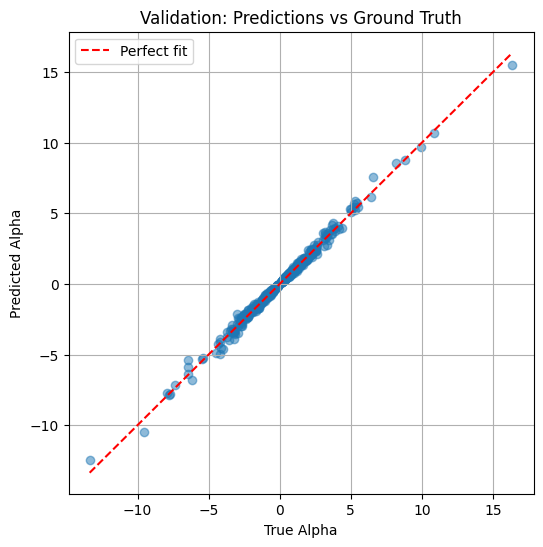

In [18]:
pred_val_alphas = predict(data_val[:500])
true_val_alphas = alpha_validation[:500]

plt.figure(figsize=(6, 6))
plt.scatter(true_val_alphas, pred_val_alphas, alpha=0.5)
plt.plot([jnp.min(true_val_alphas), jnp.max(true_val_alphas)], 
         [jnp.min(true_val_alphas), jnp.max(true_val_alphas)], 'r--', label="Perfect fit")
plt.xlabel("True Alpha")
plt.ylabel("Predicted Alpha")
plt.title("Validation: Predictions vs Ground Truth")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
pred_test_alpha = predict(data_test)

print(f"Predicted shape: {pred_test_alpha.shape}")
print(f"Sample predictions: {pred_test_alpha[:5].flatten()}")

# write npy file based on key
npy_filename = f"predictions_{key}.npy"

Predicted shape: (1000, 1)
Sample predictions: [-1.7645603   0.7827258  -0.1096344  -2.9402678   0.14931034]
